In [1]:
import pandas as pd
import re
import string
from collections import defaultdict, Counter

In [4]:
import os
import pandas as pd
from evaluation_helper_clean import predict_and_score_with_official_scorer

CHECKPOINT_DIR = "/home/omer_ahmed/Experiments/Span-models/Experiment_7_updated_discourse_model/checkpoints_2/"

ARTICLES_FOLDER = "/home/omer_ahmed/Experiments/Span-models/PTC/dev-articles"
GOLD_FILE = "/home/omer_ahmed/Experiments/Span-models/PTC/dev-task-SI.labels"
SCORER = "/home/omer_ahmed/Experiments/Span-models/task-SI_scorer.py"

results = []

for file in os.listdir(CHECKPOINT_DIR):
    if not file.endswith(".pt"):
        continue

    path = os.path.join(CHECKPOINT_DIR, file)

    print(f"\n🔥 Evaluating {file}")

    scores = predict_and_score_with_official_scorer(
        checkpoint_path=path,
        articles_folder=ARTICLES_FOLDER,
        gold_labels_file=GOLD_FILE,
        scorer_script_path=SCORER
    )

    results.append({
        "model": file,
        "precision": scores["precision"],
        "recall": scores["recall"],
        "f1": scores["f1"]
    })

# 🔥 SAVE RESULTS
df = pd.DataFrame(results)
df.sort_values("f1", ascending=False, inplace=True)

save_path = os.path.join(CHECKPOINT_DIR, "all_model_results.csv")
df.to_csv(save_path, index=False)

print("\n🏆 BEST MODELS:")
print(df.head(10))


🔥 Evaluating short_span_focus.pt


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4340.60it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Predicting: 100%|██████████| 55/55 [00:13<00:00,  4.01it/s]


2026-04-29 01:35:09,194 - INFO - Checking user submitted file
2026-04-29 01:35:09,206 - INFO - Scoring the submission with precision and recall method
2026-04-29 01:35:09,358 - INFO - Precision=306.768978/704=0.435751	Recall=484.406587/940=0.515326
2026-04-29 01:35:09,358 - INFO - F1=0.472210


📊 SPAN STATS
Total spans: 704
Avg length: 62.68
Min length: 5
Max length: 568

🔍 DEBUGGING MODEL BEHAVIOR


📄 ARTICLE 782448403
Pred spans: 5, Gold spans: 14
FP: 1, FN: 2

❌ FALSE POSITIVES:
[1385,1392] → dwarfed

⚠️ MISSED (FALSE NEGATIVES):
[1400,1411] → irreparable
[1311,1322] → irreparable

📄 ARTICLE 999001419
Pred spans: 7, Gold spans: 13
FP: 1, FN: 6

❌ FALSE POSITIVES:
[4914,4986] → Olson was solicitor general in President George W. Bush’s administration

⚠️ MISSED (FALSE NEGATIVES):
[1741,1751] → “invasion”
[3119,3125] → lawful
[2893,2906] → disappointing
[3275,3306] → a great First Amendment victory
[1319,1334] → wonderful woman

📄 ARTICLE 730081389
Pred spans: 0, Gold spans: 0
FP: 0, F

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 5660.35it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Predicting: 100%|██████████| 34/34 [00:08<00:00,  4.01it/s]


2026-04-29 01:35:39,683 - INFO - Checking user submitted file
2026-04-29 01:35:39,695 - INFO - Scoring the submission with precision and recall method
2026-04-29 01:35:39,842 - INFO - Precision=290.337973/670=0.433340	Recall=469.003488/940=0.498940
2026-04-29 01:35:39,842 - INFO - F1=0.463832


📊 SPAN STATS
Total spans: 670
Avg length: 69.49
Min length: 3
Max length: 568

🔍 DEBUGGING MODEL BEHAVIOR


📄 ARTICLE 782448403
Pred spans: 5, Gold spans: 14
FP: 2, FN: 8

❌ FALSE POSITIVES:
[1385,1392] → dwarfed
[2234,2328] → it needlessly endangered our children, our loved ones and our men and women in law enforcement

⚠️ MISSED (FALSE NEGATIVES):
[1400,1411] → irreparable
[924,993] → our children, our loved ones and our men and women in law enforcement
[875,886] → untraceable
[887,897] → ghost guns
[902,923] → needlessly endangered

📄 ARTICLE 999001419
Pred spans: 4, Gold spans: 13
FP: 0, FN: 8

❌ FALSE POSITIVES:

⚠️ MISSED (FALSE NEGATIVES):
[1435,1506] → if he misbehaves, we’ll throw him o

...

2026-04-29 01:36:16,256 - INFO - Checking user submitted file
2026-04-29 01:36:16,268 - INFO - Scoring the submission with precision and recall method
2026-04-29 01:36:16,422 - INFO - Precision=313.302595/721=0.434539	Recall=489.276961/940=0.520507
2026-04-29 01:36:16,423 - INFO - F1=0.473654


📊 SPAN STATS
Total spans: 721
Avg length: 63.02
Min length: 5
Max length: 1003

🔍 DEBUGGING MODEL BEHAVIOR


📄 ARTICLE 782448403
Pred spans: 4, Gold spans: 14
FP: 1, FN: 2

❌ FALSE POSITIVES:
[2212,2328] → Becerra’s statement, “it needlessly endangered our children, our loved ones and our men and women in law enforcement

⚠️ MISSED (FALSE NEGATIVES):
[1400,1411] → irreparable
[1311,1322] → irreparable

📄 ARTICLE 999001419
Pred spans: 8, Gold spans: 13
FP: 2, FN: 6

❌ FALSE POSITIVES:
[3367,3379] → I'm grateful
[3612,3618] → sacred

⚠️ MISSED (FALSE NEGATIVES):
[1435,1506] → if he misbehaves, we’ll throw him out or we’ll stop the news conference
[1741,1751] → “invasion”
[3119,3125] → lawful
[2893

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4786.53it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Predicting: 100%|██████████| 34/34 [00:08<00:00,  4.00it/s]


2026-04-29 01:36:47,025 - INFO - Checking user submitted file
2026-04-29 01:36:47,037 - INFO - Scoring the submission with precision and recall method
2026-04-29 01:36:47,171 - INFO - Precision=276.438171/622=0.444434	Recall=463.861171/940=0.493469
2026-04-29 01:36:47,171 - INFO - F1=0.467670


📊 SPAN STATS
Total spans: 622
Avg length: 68.83
Min length: 3
Max length: 568

🔍 DEBUGGING MODEL BEHAVIOR


📄 ARTICLE 782448403
Pred spans: 3, Gold spans: 14
FP: 0, FN: 2

❌ FALSE POSITIVES:

⚠️ MISSED (FALSE NEGATIVES):
[1400,1411] → irreparable
[1311,1322] → irreparable

📄 ARTICLE 999001419
Pred spans: 5, Gold spans: 13
FP: 1, FN: 8

❌ FALSE POSITIVES:
[3612,3618] → sacred

⚠️ MISSED (FALSE NEGATIVES):
[1435,1506] → if he misbehaves, we’ll throw him out or we’ll stop the news conference
[1741,1751] → “invasion”
[3119,3125] → lawful
[2893,2906] → disappointing
[3275,3306] → a great First Amendment victory

📄 ARTICLE 730081389
Pred spans: 0, Gold spans: 0
FP: 0, FN: 0

❌ FALSE POSITIVES:

⚠️ MIS

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4733.95it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Predicting: 100%|██████████| 34/34 [00:08<00:00,  4.00it/s]


2026-04-29 01:37:17,477 - INFO - Checking user submitted file
2026-04-29 01:37:17,488 - INFO - Scoring the submission with precision and recall method
2026-04-29 01:37:17,628 - INFO - Precision=281.199615/655=0.429312	Recall=478.970026/940=0.509543
2026-04-29 01:37:17,628 - INFO - F1=0.465999


📊 SPAN STATS
Total spans: 655
Avg length: 70.26
Min length: 3
Max length: 620

🔍 DEBUGGING MODEL BEHAVIOR


📄 ARTICLE 782448403
Pred spans: 3, Gold spans: 14
FP: 0, FN: 2

❌ FALSE POSITIVES:

⚠️ MISSED (FALSE NEGATIVES):
[1400,1411] → irreparable
[1311,1322] → irreparable

📄 ARTICLE 999001419
Pred spans: 5, Gold spans: 13
FP: 1, FN: 8

❌ FALSE POSITIVES:
[3612,3618] → sacred

⚠️ MISSED (FALSE NEGATIVES):
[1435,1506] → if he misbehaves, we’ll throw him out or we’ll stop the news conference
[1741,1751] → “invasion”
[3119,3125] → lawful
[2893,2906] → disappointing
[3275,3306] → a great First Amendment victory

📄 ARTICLE 730081389
Pred spans: 0, Gold spans: 0
FP: 0, FN: 0

❌ FALSE POSITIVES:

⚠️ MIS

In [2]:
from evaluation_helper_clean import predict_and_score_with_official_scorer

predict_and_score_with_official_scorer(
    checkpoint_path="/home/omer_ahmed/Experiments/Span-models/Experiment_7_updated_discourse_model/best_span_roberta_pos_ner_discourse_updated.pt",
    articles_folder="/home/omer_ahmed/Experiments/Span-models/PTC/dev-articles",
    gold_labels_file="/home/omer_ahmed/Experiments/Span-models/PTC/dev-task-SI.labels",
    scorer_script_path="/home/omer_ahmed/Experiments/Span-models/task-SI_scorer.py"
)

/home/omer_ahmed/Experiments/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 3116.57it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those

2026-05-03 14:23:40,570 - INFO - Checking user submitted file
2026-05-03 14:23:40,582 - INFO - Scoring the submission with precision and recall method
2026-05-03 14:23:40,712 - INFO - Precision=319.157864/690=0.462548	Recall=472.373440/940=0.502525
2026-05-03 14:23:40,712 - INFO - F1=0.481708


📊 SPAN STATS
Total spans: 690
Avg length: 56.34
Min length: 3
Max length: 510

🔍 DEBUGGING MODEL BEHAVIOR


📄 ARTICLE 782448403
Pred spans: 5, Gold spans: 14
FP: 1, FN: 2

❌ FALSE POSITIVES:
[327,337] → ghost guns

⚠️ MISSED (FALSE NEGATIVES):
[1400,1411] → irreparable
[1311,1322] → irreparable

📄 ARTICLE 999001419
Pred spans: 11, Gold spans: 13
FP: 6, FN: 7

❌ FALSE POSITIVES:
[14,18] → Kick
[233,251] → to kick Acosta out
[3478,3496] → we passed the test
[3862,3873] → our leaders
[4435,4449] → to boot Acosta

⚠️ MISSED (FALSE NEGATIVES):
[1837,1850] → belligerently
[1435,1506] → if he misbehaves, we’ll throw him out or we’ll stop the news conference
[1741,1751] → “invasion”
[3119,3125] → lawful

{'precision': 0.462548, 'recall': 0.502525, 'f1': 0.481708}

In [1]:
import torch
ckpt = torch.load("best_span_roberta_pos_ner_discourse_updated.pt")

print(ckpt["cfg"])

{'model_name': 'roberta-large', 'max_length': 512, 'stride': 384, 'batch_size': 2, 'lr': 2e-05, 'weight_decay': 0.01, 'epochs': 5, 'warmup_ratio': 0.1, 'num_workers': 2, 'seed': 42, 'lstm_hidden': 512, 'lstm_layers': 1, 'pos_dim': 32, 'ner_dim': 32, 'discourse_dim': 16, 'discourse_input_dim': 11, 'dropout': 0.2, 'save_path': 'best_span_roberta_pos_ner_discourse_updated.pt', 'class_weights': (1.0, 1.0, 1.0, 1.0, 1.0), 'ce_loss_weight': 0.0, 'crf_loss_weight': 1.0, 'min_token_overlap_ratio': 0.0, 'pos_scale': 0.3, 'ner_scale': 0.3, 'discourse_scale': 0.3}


### Evaluation

In [51]:
def normalize_article_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s


def normalize_span_text(span_text, lowercase=True):
    """
    Normalize an already extracted span snippet.
    """
    if span_text is None:
        return ""

    span_text = str(span_text).strip()

    if lowercase:
        span_text = span_text.lower()

    # trim edge punctuation/quotes
    span_text = span_text.strip(string.punctuation + "“”‘’\"'")

    # collapse whitespace
    span_text = re.sub(r"\s+", " ", span_text).strip()

    return span_text


def build_gold_span_texts(test_data_df):
    gold_texts_by_article = defaultdict(list)

    df = test_data_df.copy()
    df["article_id_norm"] = df["article_id"].apply(normalize_article_id)

    grouped = df.groupby("article_id_norm")

    for article_id, g in grouped:
        if article_id is None:
            continue

        full_text = g["article_text"].iloc[0]
        if full_text is None or (isinstance(full_text, float) and pd.isna(full_text)):
            continue

        full_text = str(full_text)

        spans = (
            g[["span_start", "span_end"]]
            .dropna()
            .drop_duplicates()
            .sort_values(["span_start", "span_end"])
            .values.tolist()
        )

        for start, end in spans:
            start, end = int(start), int(end)

            if start < 0 or end > len(full_text) or start >= end:
                continue

            snippet = full_text[start:end]
            norm_snippet = normalize_span_text(snippet)

            gold_texts_by_article[article_id].append({
                "offsets": (start, end),
                "text": snippet,
                "norm_text": norm_snippet
            })

    return gold_texts_by_article


def build_pred_span_texts(predictions_dict, test_data_df):
    df = test_data_df.copy()
    df["article_id_norm"] = df["article_id"].apply(normalize_article_id)

    text_lookup = dict(zip(df["article_id_norm"], df["article_text"]))
    pred_texts_by_article = defaultdict(list)

    for article_id, spans in predictions_dict.items():
        article_id = normalize_article_id(article_id)
        if article_id is None:
            continue

        full_text = text_lookup.get(article_id, None)
        if full_text is None or (isinstance(full_text, float) and pd.isna(full_text)):
            continue

        full_text = str(full_text)

        for start, end in spans:
            start, end = int(start), int(end)

            if start < 0 or end > len(full_text) or start >= end:
                continue

            snippet = full_text[start:end]
            norm_snippet = normalize_span_text(snippet)

            pred_texts_by_article[article_id].append({
                "offsets": (start, end),
                "text": snippet,
                "norm_text": norm_snippet
            })

    return pred_texts_by_article


def relaxed_text_span_f1(pred_texts_by_article, gold_texts_by_article):
    tp = fp = fn = 0

    all_article_ids = set(pred_texts_by_article.keys()) | set(gold_texts_by_article.keys())

    for article_id in all_article_ids:
        pred_norms = [x["norm_text"] for x in pred_texts_by_article.get(article_id, [])]
        gold_norms = [x["norm_text"] for x in gold_texts_by_article.get(article_id, [])]

        pred_counter = Counter(pred_norms)
        gold_counter = Counter(gold_norms)

        common = pred_counter & gold_counter
        tp += sum(common.values())
        fp += sum((pred_counter - gold_counter).values())
        fn += sum((gold_counter - pred_counter).values())

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        "relaxed_text_precision": precision,
        "relaxed_text_recall": recall,
        "relaxed_text_f1": f1,
        "tp": tp,
        "fp": fp,
        "fn": fn,
    }
def tolerant_span_evaluation(
    pred_texts_by_article,
    gold_texts_by_article,
    start_tolerance=5,
    end_tolerance=5
):
    tp_exact = 0
    tp_near = 0
    fp = 0
    fn = 0
    rows = []

    all_article_ids = set(pred_texts_by_article.keys()) | set(gold_texts_by_article.keys())

    for article_id in all_article_ids:
        preds = pred_texts_by_article.get(article_id, [])
        golds = gold_texts_by_article.get(article_id, [])

        gold_used = [False] * len(golds)
        pred_used = [False] * len(preds)

        # exact matches
        for p_idx, pred in enumerate(preds):
            ps, pe = pred["offsets"]

            for g_idx, gold in enumerate(golds):
                if gold_used[g_idx]:
                    continue

                gs, ge = gold["offsets"]

                if ps == gs and pe == ge:
                    tp_exact += 1
                    gold_used[g_idx] = True
                    pred_used[p_idx] = True

                    rows.append({
                        "article_id": article_id,
                        "type": "exact_tp",
                        "pred_index": p_idx,
                        "gold_index": g_idx,
                        "pred_start": ps,
                        "pred_end": pe,
                        "gold_start": gs,
                        "gold_end": ge,
                        "pred_text": pred["text"],
                        "gold_text": gold["text"],
                        "pred_norm_text": pred["norm_text"],
                        "gold_norm_text": gold["norm_text"],
                        "start_diff": 0,
                        "end_diff": 0
                    })
                    break

        # near matches
        for p_idx, pred in enumerate(preds):
            if pred_used[p_idx]:
                continue

            ps, pe = pred["offsets"]
            best_match = None
            best_score = float("inf")

            for g_idx, gold in enumerate(golds):
                if gold_used[g_idx]:
                    continue

                gs, ge = gold["offsets"]
                start_diff = abs(ps - gs)
                end_diff = abs(pe - ge)

                if start_diff <= start_tolerance and end_diff <= end_tolerance:
                    score = start_diff + end_diff
                    if score < best_score:
                        best_score = score
                        best_match = (g_idx, gs, ge, start_diff, end_diff, gold)

            if best_match is not None:
                g_idx, gs, ge, start_diff, end_diff, gold = best_match
                tp_near += 1
                gold_used[g_idx] = True
                pred_used[p_idx] = True

                rows.append({
                    "article_id": article_id,
                    "type": "near_tp",
                    "pred_index": p_idx,
                    "gold_index": g_idx,
                    "pred_start": ps,
                    "pred_end": pe,
                    "gold_start": gs,
                    "gold_end": ge,
                    "pred_text": pred["text"],
                    "gold_text": gold["text"],
                    "pred_norm_text": pred["norm_text"],
                    "gold_norm_text": gold["norm_text"],
                    "start_diff": start_diff,
                    "end_diff": end_diff
                })

        # fp
        for p_idx, pred in enumerate(preds):
            if not pred_used[p_idx]:
                ps, pe = pred["offsets"]
                fp += 1
                rows.append({
                    "article_id": article_id,
                    "type": "fp",
                    "pred_index": p_idx,
                    "gold_index": None,
                    "pred_start": ps,
                    "pred_end": pe,
                    "gold_start": None,
                    "gold_end": None,
                    "pred_text": pred["text"],
                    "gold_text": None,
                    "pred_norm_text": pred["norm_text"],
                    "gold_norm_text": None,
                    "start_diff": None,
                    "end_diff": None
                })

        # fn
        for g_idx, gold in enumerate(golds):
            if not gold_used[g_idx]:
                gs, ge = gold["offsets"]
                fn += 1
                rows.append({
                    "article_id": article_id,
                    "type": "fn",
                    "pred_index": None,
                    "gold_index": g_idx,
                    "pred_start": None,
                    "pred_end": None,
                    "gold_start": gs,
                    "gold_end": ge,
                    "pred_text": None,
                    "gold_text": gold["text"],
                    "pred_norm_text": None,
                    "gold_norm_text": gold["norm_text"],
                    "start_diff": None,
                    "end_diff": None
                })

    tp_total = tp_exact + tp_near
    precision = tp_total / (tp_total + fp + 1e-8)
    recall = tp_total / (tp_total + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    results = {
        "tp_exact": tp_exact,
        "tp_near": tp_near,
        "tp_total": tp_total,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    match_df = pd.DataFrame(rows)
    return results, match_df





def show_relaxed_matches_for_article(article_id, pred_texts_by_article, gold_texts_by_article):
    """
    Prints predicted and gold span texts for one article after normalization.
    Useful for inspection.
    """
    article_id = str(article_id)

    preds = pred_texts_by_article.get(article_id, [])
    golds = gold_texts_by_article.get(article_id, [])

    print(f"\n===== ARTICLE {article_id} =====")

    print("\nPredicted spans:")
    if preds:
        for x in preds:
            print(f"  raw={x['text']!r} | norm={x['norm_text']!r} | offsets={x['offsets']}")
    else:
        print("  None")

    print("\nGold spans:")
    if golds:
        for x in golds:
            print(f"  raw={x['text']!r} | norm={x['norm_text']!r} | offsets={x['offsets']}")
    else:
        print("  None")
import pandas as pd
from collections import Counter, defaultdict

def get_relaxed_match_dataframes(
    pred_texts_by_article,
    gold_texts_by_article,
    max_offset_distance=10
):
    """
    Returns two DataFrames:

    1. matched_df:
       predicted/gold span pairs whose normalized text matches
       within the same article.

    2. near_offset_df:
       predicted/gold span pairs within the same article whose
       offsets are close to each other, based on start/end differences.

    Parameters
    ----------
    pred_texts_by_article : dict
    gold_texts_by_article : dict
    max_offset_distance : int
        Maximum allowed difference for start/end offsets to count as "near".

    Notes
    -----
    - Exact relaxed matching is done by normalized text within each article.
    - Near-offset pairs are collected regardless of text match.
    """

    matched_rows = []
    near_rows = []

    all_article_ids = set(pred_texts_by_article.keys()) | set(gold_texts_by_article.keys())

    for article_id in all_article_ids:
        preds = pred_texts_by_article.get(article_id, [])
        golds = gold_texts_by_article.get(article_id, [])

        # -------------------------------------------------
        # 1. TEXT-BASED MATCHES (multiset matching)
        # -------------------------------------------------
        gold_used = [False] * len(golds)

        for p_idx, pred in enumerate(preds):
            matched = False
            for g_idx, gold in enumerate(golds):
                if gold_used[g_idx]:
                    continue

                if pred["norm_text"] == gold["norm_text"]:
                    ps, pe = pred["offsets"]
                    gs, ge = gold["offsets"]

                    matched_rows.append({
                        "article_id": article_id,
                        "pred_index": p_idx,
                        "gold_index": g_idx,
                        "pred_start": ps,
                        "pred_end": pe,
                        "gold_start": gs,
                        "gold_end": ge,
                        "pred_text": pred["text"],
                        "gold_text": gold["text"],
                        "pred_norm_text": pred["norm_text"],
                        "gold_norm_text": gold["norm_text"],
                        "start_diff": abs(ps - gs),
                        "end_diff": abs(pe - ge),
                        "span_length_diff": abs((pe - ps) - (ge - gs)),
                    })
                    gold_used[g_idx] = True
                    matched = True
                    break

        # -------------------------------------------------
        # 2. NEAR-OFFSET PAIRS
        # -------------------------------------------------
        for p_idx, pred in enumerate(preds):
            ps, pe = pred["offsets"]

            for g_idx, gold in enumerate(golds):
                gs, ge = gold["offsets"]

                start_diff = abs(ps - gs)
                end_diff = abs(pe - ge)

                # overlap amount
                overlap_start = max(ps, gs)
                overlap_end = min(pe, ge)
                overlap_len = max(0, overlap_end - overlap_start)

                # near if either boundary is close, or spans overlap
                is_near = (
                    start_diff <= max_offset_distance
                    or end_diff <= max_offset_distance
                    or overlap_len > 0
                )

                if is_near:
                    near_rows.append({
                        "article_id": article_id,
                        "pred_index": p_idx,
                        "gold_index": g_idx,
                        "pred_start": ps,
                        "pred_end": pe,
                        "gold_start": gs,
                        "gold_end": ge,
                        "pred_text": pred["text"],
                        "gold_text": gold["text"],
                        "pred_norm_text": pred["norm_text"],
                        "gold_norm_text": gold["norm_text"],
                        "start_diff": start_diff,
                        "end_diff": end_diff,
                        "span_length_diff": abs((pe - ps) - (ge - gs)),
                        "overlap_len": overlap_len,
                        "same_norm_text": pred["norm_text"] == gold["norm_text"],
                    })

    matched_df = pd.DataFrame(matched_rows)
    near_offset_df = pd.DataFrame(near_rows)

    # Optional sorting
    if not matched_df.empty:
        matched_df = matched_df.sort_values(
            ["article_id", "start_diff", "end_diff"]
        ).reset_index(drop=True)

    if not near_offset_df.empty:
        near_offset_df = near_offset_df.sort_values(
            ["article_id", "start_diff", "end_diff", "overlap_len"],
            ascending=[True, True, True, False]
        ).reset_index(drop=True)

    return matched_df, near_offset_df
def get_best_near_matches(near_offset_df):
    """
    Keep only the best gold match for each predicted span within an article.
    Ranking prefers:
    1. larger overlap
    2. smaller start diff
    3. smaller end diff
    """
    if near_offset_df.empty:
        return near_offset_df.copy()

    df = near_offset_df.copy()

    df = df.sort_values(
        by=["article_id", "pred_index", "overlap_len", "start_diff", "end_diff"],
        ascending=[True, True, False, True, True]
    )

    best_df = df.groupby(["article_id", "pred_index"], as_index=False).first()
    return best_df


In [52]:
# Build reconstructed gold and predicted span texts
gold_span_texts = build_gold_span_texts(test_df)
pred_span_texts = build_pred_span_texts(pred_spans, test_df)

# Compute relaxed text-only metric
relaxed_metrics = relaxed_text_span_f1(pred_span_texts, gold_span_texts)

print("\n===== RELAXED TEXT-ONLY RESULTS =====")
for k, v in relaxed_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")
matched_df, near_offset_df = get_relaxed_match_dataframes(
    pred_span_texts,
    gold_span_texts,
    max_offset_distance=10
)


===== RELAXED TEXT-ONLY RESULTS =====
relaxed_text_precision: 0.4521
relaxed_text_recall: 0.3889
relaxed_text_f1: 0.4181
tp: 646
fp: 783
fn: 1015


In [53]:
best_near_df = get_best_near_matches(near_offset_df)
# best_near_df

In [19]:
# show_relaxed_matches_for_article("111111114", pred_span_texts, gold_span_texts)

In [54]:
results, match_df = tolerant_span_evaluation(
    pred_span_texts,
    gold_span_texts,
    start_tolerance=10,
    end_tolerance=10
)
print("\n===== TOLERANT SPAN EVALUATION RESULTS =====")
print(f"TP (exact): {results['tp_exact']}")
print(f"TP (near): {results['tp_near']}")
print(f"FP: {results['fp']}")
print(f"FN: {results['fn']}")
print(f"Precision: {results['precision']:.4f}")
print(f"Recall: {results['recall']:.4f}")
print(f"F1: {results['f1']:.4f}")
match_df[match_df["type"] == "near_tp"]


===== TOLERANT SPAN EVALUATION RESULTS =====
TP (exact): 574
TP (near): 199
FP: 656
FN: 888
Precision: 0.5409
Recall: 0.4654
F1: 0.5003


,article_id,type,pred_index,gold_index,pred_start,pred_end,gold_start,gold_end,pred_text,gold_text,pred_norm_text,gold_norm_text,start_diff,end_diff
2,11227,near_tp,0.0,0.0,57.0,89.0,59.0,85.0,to unleash the full ferocity\n7of,unleash the full ferocity,to unleash the full ferocity 7of,unleash the full ferocity,2.0,4.0
27,43,near_tp,0.0,0.0,8.0,61.0,0.0,61.0,"if this crisis continues, many people will go ...","Because if this crisis continues, many people ...","if this crisis continues, many people will go ...","because if this crisis continues, many people ...",8.0,0.0
28,10151,near_tp,0.0,0.0,56.0,106.0,55.0,106.0,London's ICU nurses detail depression and disa...,\nLondon's ICU nurses detail depression and di...,london's icu nurses detail depression and disa...,london's icu nurses detail depression and disa...,1.0,0.0
31,11531,near_tp,0.0,0.0,93.0,135.0,93.0,136.0,who would rather focus on life-threatening,who would rather focus on life-threatening,who would rather focus on life-threatening,who would rather focus on life-threatening,0.0,1.0
61,774145019,near_tp,5.0,11.0,2821.0,2829.0,2825.0,2829.0,The very,very,the very,very,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2230,8265,near_tp,0.0,0.0,9.0,30.0,0.0,30.0,"reign of an autocrat,","The long reign of an autocrat,",reign of an autocrat,the long reign of an autocrat,9.0,0.0
2253,10183,near_tp,0.0,0.0,11.0,38.0,10.0,38.0,this in a really depressing,this in a really depressing,this in a really depressing,this in a really depressing,1.0,0.0
2260,7381,near_tp,0.0,0.0,74.0,97.0,73.0,97.0,importance” of American,“importance” of American,importance” of american,importance” of american,1.0,0.0
2264,10439,near_tp,0.0,0.0,35.0,51.0,43.0,61.0,weekend from our,from our 8 allies,weekend from our,from our 8 allies,8.0,10.0


In [55]:
import numpy as np
df = match_df.copy()
def lookup_techniques(row):
    matches = test_df[
        (test_df['article_id'] == row['article_id']) &
        (test_df['span_start'] == row['gold_start']) &
        (test_df['span_end'] == row['gold_end'])
    ]
    
    
    techniques = []
    
    for t in matches['techniques']:
        if isinstance(t, list):
            techniques.extend(t)
        elif isinstance(t, np.ndarray):
            techniques.extend(t.tolist())  # 🔥 fix here
        elif pd.notna(t):
            techniques.append(t)
    
    return list(set(techniques))
df['techniques'] = df.apply(lookup_techniques, axis=1)

In [56]:
df_exploded = df.explode('techniques')
summary = (
    df_exploded
    .groupby(['techniques', 'type'])
    .size()
    .unstack(fill_value=0)
)

summary['correct'] = summary.get('exact_tp', 0) + summary.get('near_tp', 0)
summary['wrong'] = summary.get('fn', 0)

summary = summary[['correct', 'wrong']]

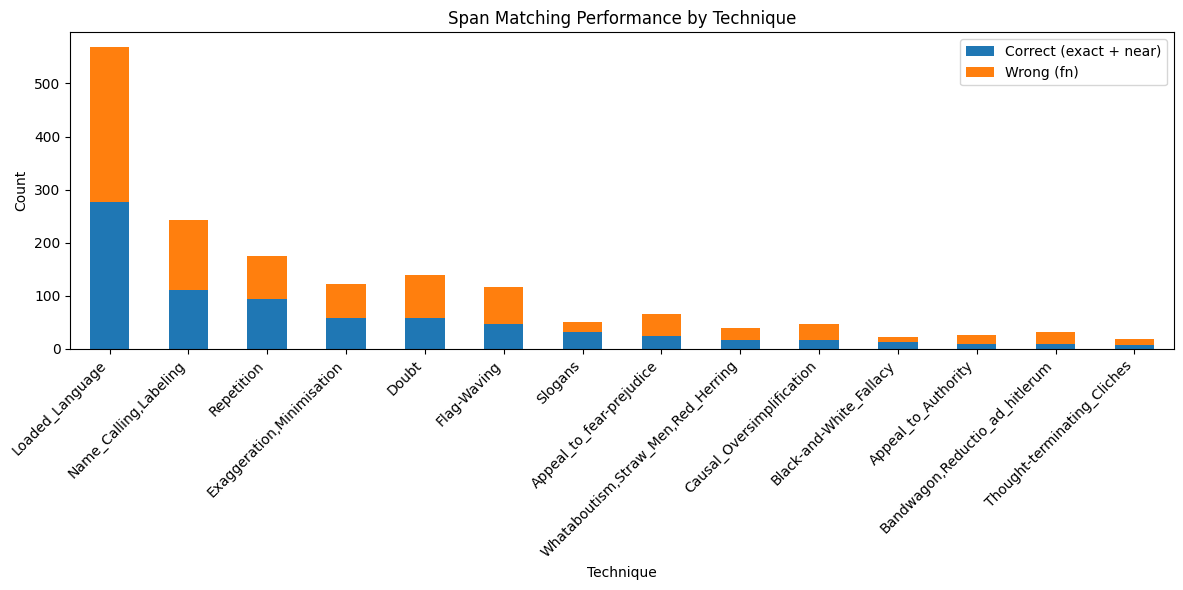

In [57]:
import matplotlib.pyplot as plt

summary.sort_values('correct', ascending=False).plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Span Matching Performance by Technique')
plt.ylabel('Count')
plt.xlabel('Technique')
plt.xticks(rotation=45, ha='right')
plt.legend(['Correct (exact + near)', 'Wrong (fn)'])
plt.tight_layout()
plt.show()

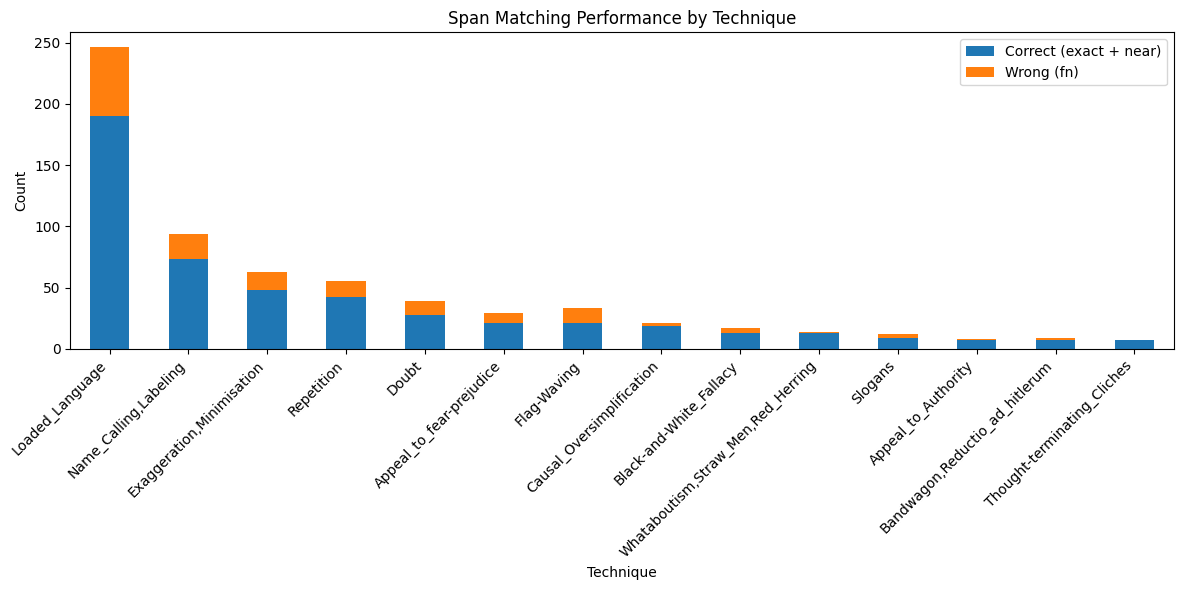

In [49]:
import matplotlib.pyplot as plt

summary.sort_values('correct', ascending=False).plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Span Matching Performance by Technique')
plt.ylabel('Count')
plt.xlabel('Technique')
plt.xticks(rotation=45, ha='right')
plt.legend(['Correct (exact + near)', 'Wrong (fn)'])
plt.tight_layout()
plt.show()